In [1]:
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.stats
from scipy.stats import norm
import saga

In [2]:
from load_samples import load_samples_sim, Samples, parse_saga_file, load_histograms_hw, load_samples_hw

samples_sim = load_samples_sim()
biggest_samples = sorted(samples_sim, key=lambda sample: len(sample.samples), reverse=True)
big_samples = [s for s in biggest_samples if len(s.samples) > 50000]
samples_kat = parse_saga_file("sampler_fpemu.txt")

hists_hw = load_histograms_hw()
samples_hw = load_samples_hw()

In [17]:
def plot_histogram(samples: Samples, axs=None, labeled=False):
    fig = None
    if axs is None:
        fig, axs = plt.subplots(1, 1)

    if samples.samples is not None:
        unique_values, counts = np.unique(samples.samples, return_counts=True)
    elif samples.histogram is not None:
        unique_values, counts = samples.histogram
        unique_values = np.array(unique_values)
        counts = np.array(counts)
    else:
        raise ValueError("No histogram given")

    total = np.sum(counts)
    probabilities = counts / total

    bars = axs.bar(unique_values, probabilities, alpha=0.6, color='g', label='Samples')
    if labeled:
        axs.bar_label(bars, [f"{x}" for x in counts], label_type='center', rotation=90, color='black')
    axs.axvline(samples.mu, color='r', linestyle='dashed', linewidth=2, label=f'Mean (μ)')

    # Calculate the discrete Gaussian
    extra = 10
    x = np.arange(min(unique_values)-extra, max(unique_values)+extra) # extend for more accurate normalization
    discrete_gaussian = norm.pdf(x, samples.mu, samples.sigma)
    discrete_gaussian /= discrete_gaussian.sum()
    # trim excess
    x = x[extra:-extra+1]
    discrete_gaussian = discrete_gaussian[extra:-extra+1]
    axs.plot(x, discrete_gaussian, color='b', marker='o', label='Discrete Gaussian')

    # Add annotations for sigma, number of samples, and mu
    axs.annotate(f'μ: {samples.mu:.4f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, color='black')
    axs.annotate(f'σ: {samples.sigma:.4f}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10, color='black')
    axs.annotate(f'N: {total}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10, color='black')

    # Set integer tick values on the X-axis
    x_ticks = range(int(min(unique_values)), int(max(unique_values)) + 1)
    axs.set_xticks(x_ticks)

    axs.set_xlabel('Value')
    axs.set_ylabel('Density')
    axs.legend()

    if fig is not None:
        plt.show()

def univariate(s: Samples, pmin = 0.001) -> Optional[saga.UnivariateSamples]:
    if s.samples is None or len(s.samples) == 0:
        return None
    try:
        return saga.UnivariateSamples(s.mu, s.sigma, s.samples, pmin)
    except ValueError as e: # chisquare test preconditions failed
        print(f"Error: {e}")
        return None

def dataset_sizes(samples: list[Samples]):
    sizemap = {}
    for s in samples:
        if s.samples is not None:
            l = len(s.samples)
            if l in sizemap:
                sizemap[l] += 1
            else:
                sizemap[l] = 1
    # sort and print
    sizemap = sorted(sizemap.items(), key=lambda item: item[1], reverse=True)
    print(f"Dataset sizes: {", ".join([f'{v}x {k}' for k, v in sizemap])}")

def save_chi_dataset(uni: list[tuple[Samples, saga.UnivariateSamples]], fisher: tuple[float, float], filename: str):
    with open(filename, 'w') as f:
        f.write("Fisher statistic, Fisher p-value\n")
        f.write(f"{fisher[0]}, {fisher[1]}\n")
        f.write("Sample, Chi2 statistic, Chi2 p-value\n")
        for s, u in uni:
            if u is not None:
                f.write(f"{s.filename}, {u.chi2_stat}, {u.chi2_pvalue}\n")
            else:
                f.write(f"{s.filename}, None, None\n")

def report_combine_pvalues(uni: list[tuple[Samples, saga.UnivariateSamples]], pmin = 0.05) -> tuple[float, float]:
    pvalues = [t[1].chi2_pvalue for t in uni if t[1] is not None]
    # pvalue histogram
    plt.hist(pvalues, bins=50, alpha=0.5, color='g', label='P-values')
    fisher_stat, fisher_pvalue = scipy.stats.combine_pvalues(pvalues, method='fisher')
    print(f"Fisher statistic: {fisher_stat}")
    print(f"Fisher p-value: {fisher_pvalue} (should be > {pmin})")
    print(f"Dataset invalid: {fisher_pvalue < pmin}")
    return fisher_stat, fisher_pvalue

def report_univariate(lst: list[Samples], pmin = 0.05):
    pmin_bonferroni = pmin / len(lst) # use bonferroni while testing each sample set individually
    uni = [(s, univariate(s, pmin_bonferroni)) for s in lst]
    failed = [s for s in uni if s[1] is not None and not s[1].is_valid]
    invalid = len([s for s in uni if s[1] is None])
    for f in failed:
        print(f'Failed samples: {f[0].filename}')
        print(f[1])
        plot_histogram(f[0], labeled=True)
    print(f"Total: {len(lst)}")
    print(f"Invalid: {invalid}")
    print(f"Failed: {len(failed)}")
    return uni



In [4]:
%%script false --no-raise-error
fig, axs = plt.subplots(5, 5, figsize=(30, 30))
for x, y in np.ndindex(axs.shape):
    ax = axs[x, y]
    i = x * axs.shape[1] + y
    s = big_samples[i]
    ax.set_title(f"Sample {i}")
    plot_histogram(s, ax)

fig.tight_layout()
fig.savefig("samplerz_sim_histograms_5x5.pdf")
fig.show()

In [5]:
%%script false --no-raise-error
selected = [big_samples[i] for i in [5, 8, 19, 17, 10, 12]]
fig, axs = plt.subplots(3, 2, figsize=(13, 12), sharey=True)
for x, y in np.ndindex(axs.shape):
    ax = axs[x, y]
    i = x * axs.shape[1] + y
    s = selected[i]
    # ax.set_title(f"Sample {i}")
    plot_histogram(s, ax)
fig.tight_layout()
fig.savefig("samplerz_sim_histograms_3x2.pdf")
fig.show()

In [ ]:
%%script false --no-raise-error
fig, axs = plt.subplots(3, 2, figsize=(20, 10), sharey=True)
for x, y in np.ndindex(axs.shape):
    ax = axs[x, y]
    i = y + x * axs.shape[1]
    s = hists_hw[i]
    plot_histogram(s, ax, labeled=True)
    ax.set_title(f"Sample set {i} (log)")
    ax.set_yscale('log')

fig.tight_layout()
fig.savefig("samplerz_hw_histograms_3x2.pdf")
fig.show()


Dataset sizes: 1000x 1000
Total: 1000
Invalid: 0
Failed: 0
Fisher statistic: 1978.3757853032002
Fisher p-value: 0.6302812102295272 (should be > 0.05)
Dataset invalid: False


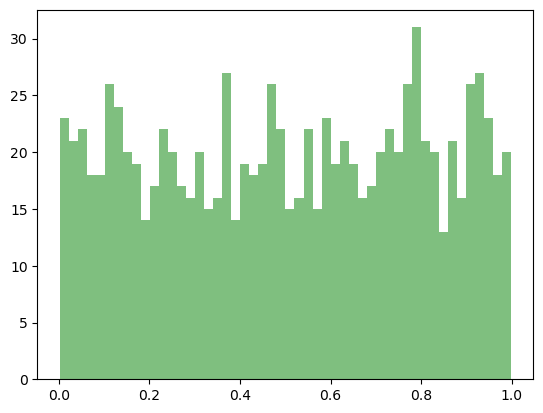

In [19]:
dataset_sizes(samples_kat)
uni = report_univariate(samples_kat)
fisher = report_combine_pvalues(uni)
save_chi_dataset(uni, fisher, "pvalues_kat_samples.csv")

Dataset sizes: 1x 10228, 1x 10151, 1x 10114, 1x 10173, 1x 10192, 1x 10017, 1x 10132, 1x 10126, 1x 10191, 1x 10078, 1x 10088, 1x 10049, 1x 10066, 1x 9965, 1x 10143, 1x 10138, 1x 10162, 1x 10063, 1x 10021, 1x 10034
Total: 20
Invalid: 0
Failed: 0
Fisher statistic: 36.90904550511311
Fisher p-value: 0.6101816700457525 (should be > 0.05)
Dataset invalid: False


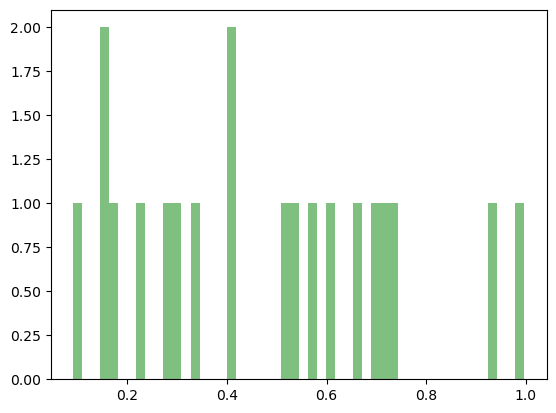

In [20]:
dataset_sizes(samples_sim)
uni = report_univariate(samples_sim)
fisher = report_combine_pvalues(uni)
save_chi_dataset(uni, fisher, "pvalues_sim_samples.csv")

Dataset sizes: 2000x 100000
Total: 2000
Invalid: 0
Failed: 0
Fisher statistic: 4098.037217671528
Fisher p-value: 0.13682425325918646 (should be > 0.05)
Dataset invalid: False


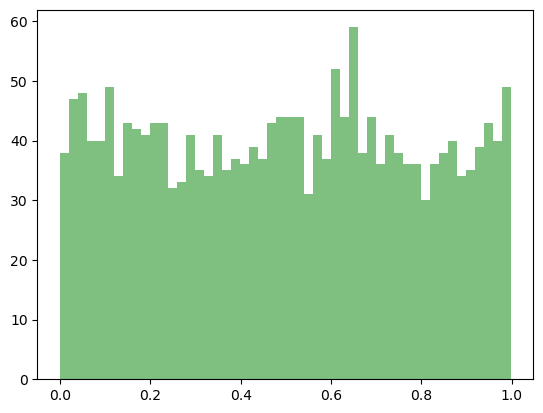

In [21]:
dataset_sizes(samples_hw)
uni = report_univariate(samples_hw)
fisher = report_combine_pvalues(uni)
save_chi_dataset(uni, fisher, "pvalues_hw_samples.csv")